# Imports

# About SSIM

Structural Similarity Index Measure(SSIM): a method for predicting the perceived quality of digital television and cinematic pictures, as well as other kinds of digital images and videos

It is a method for comparing the similarity between two images based on three factors: `luminance`(휘도), `contrast`(대조), and `structure`(구조). The reason these specific factors are used for comparison is that the human visual system perceives images in a similar manner.

## Luminance

The image's pixel values ​​are used directly, rather than extracting and using a separate luminance component.

$$\mu_x = \frac{1}{N} \sum_{i=1}^{n} x_i$$

$x_i$ = Value of each pixel(refers to the brightness value)  
$N$ = Totla number of pixels  
$\mu_x$ = Mean of image's luminance 

$\mu_x$ is used to compare the difference of luminance of two images. Let's say two images are $x,\ y$ the formula to compare luminace of the two images is as follows

$$l(x,y) = \frac{2\mu_x\mu_y + C_1}{\mu_x^2+\mu_y^2+C_1}$$

Here, $C_1$ is a constant variable which was added to ensure stability and prevent the denominator from becoming zero. And it is defined as below.

$$C_1 = (K_1L)^2$$

$K_1$ = 0.01  
$L$ = 255  
$\therefore C_1 = 6.5025$

If the value of $\mu_x$ and $\mu_y$ are similar the value of $l(x,y)$ gets close to 1   
and if they are far different the value of $l(x,y)$ gets close to 0.

## Contrast

This quantity represents the degree to which light intensity varies within an image.  
Since this value can be quantified by measuring the difference in values ​​between pixels, the standard deviation(표준편차) is used.

$$\sigma_x = (\frac{1}{N-1}\Sigma_{i=1}^{N}(x_i-\mu_x)^2)^\frac{1}{2}$$

$N-1$: Since we are calculating the sample standard deviation, we use $N-1$ to ensure that the sample standard deviation serves as an estimate of the population standard deviation.  
$\sigma_x$: Standard deviation between pixels of an image.

$\sigma_x$ is used to compare two image's constrast factor. It is similar to $l(x,y)$

$$c(x,y) = \frac{2\sigma_x\sigma_y + C_2}{\sigma_x^2+\sigma_y^2+C_2}$$

Here, $C_2$ is a constant variable. And it is defined as below.

$$C_2 = (K_2L)^2$$

$K_2$ = 0.03  
$\therefore C_2 = 58.5225$

## Structure

It represents structural differences in pixel values ​​and, when qualitatively identifying components, indicates edges.  
Pixel values ​​are redefined based on the distribution of normalized pixel values, using luminance as the mean and contrast as the standard deviation.

$$\frac{(X-\mu_x)}{\sigma_x}$$

$X$: Input image

Verifying the similarity of the structural components of two images is equivalent to utilizing the correlation between them.

$$corr(X,Y) = \frac{\sigma_xy}{\sigma_x\sigma_y} = \frac{E[(x-\mu_x)(y-\mu_y)]}{\sigma_x\sigma_y} = E[\frac{(x-\mu_x)(y-\mu_y)}{\sigma_x\sigma_y}]\\ 
= E[\frac{(x-\mu_x)}{\sigma_x}\frac{(y-\mu_y)}{\sigma_y}]

Therefore, calculating the correlation between two images is equivalent to finding the average of the product of their structural components.

Therefore, a function that compares the structures of the two images can be defined as follows.

$$s(x,y)=\frac{\sigma_xy + C_3}{\sigma_x\sigma_y + C_3}$$

$$\sigma_xy = \frac{1}{N-1}\Sigma_{i=1}^{N}(x_i-\mu_x)(y_i-\mu_y)$$

$C_3 = \frac{C_2}{2}$  
The reason is that SSIM is defined as the product of $l(x, y)$, $c(x, y)$, and $s(x, y)$, and the equation can be simplified by setting $C_3 = \frac{C_2}{2}$.

## Full SSIM Equation

SSIM, which determines image similarity by accounting for `luminance`, `contrast`, and `structure`, is defined as follows:

$$SSIM(x,y) = l(x,y)^\alpha * c(x,y)^\beta * s(x,y)^\gamma$$

If $\alpha,\ \beta,\ \gamma>0$, we can set the relative importance between `luminance`, `contrast`, `structure`  
To simplify this equation, let's set $\alpha,\ \beta,\ \gamma = 1$ and set $C_3 =C_2/2$

$$SSIM(x,y) = l(x,y) * c(x,y) * s(x,y) = \frac{2\mu_x\mu_y + C_1}{\mu_x^2+\mu_y^2+C_1}\ \frac{2\sigma_x\sigma_y + C_2}{\sigma_x^2+\sigma_y^2+C_2}\ \frac{\sigma_xy + C_2/2}{\sigma_x\sigma_y + C_2/2}\\
= \frac{(2\mu_x\mu_y+C_1)(2\sigma_xy+C_2)}{(\mu_x^2+\mu_y^2+C_1)(\sigma_x^2+\sigma_y^2+C_2)}$$

# What is fused SSIM?

Fused SSIM is just computing SSIM multiple times in a fast way. Same equation, same results, but fast

# Tutorial

In [9]:
import torch  
import torch.nn.functional as F 
import numpy as np
import math
import cv2

def gaussian(window_size, sigma):
    """
    Generates a list of Tensor values drawn from a gaussian distribution with standard
    diviation = sigma and sum of all elements = 1.

    Length of list = window_size
    """    
    gauss =  torch.Tensor([math.exp(-(x - window_size//2)**2/float(2*sigma**2)) for x in range(window_size)])
    return gauss/gauss.sum()

def create_window(window_size, channel=1):

    # Generate an 1D tensor containing values sampled from a gaussian distribution
    # _1d_window : (window_size, 1)
    # sum of _1d_window = 1
    _1d_window = gaussian(window_size=window_size, sigma=1.5).unsqueeze(1)
    
    # Converting to 2D  : _1d_window (window_size, 1) @ _1d_window.T (1, window_size)
    # _2d_window : (window_size, window_size)
    # sum of _2d_window = 1
    _2d_window = _1d_window.mm(_1d_window.t()).float().unsqueeze(0).unsqueeze(0)
     
    # expand _2d_window to window size
    # window : (channel, 1, window_size, window_size)
    window = torch.Tensor(_2d_window.expand(channel, 1, window_size, window_size).contiguous())

    return window

def ssim(img1, img2, window_size=11, val_range=255, window=None, size_average=True, full=False):

    # L is the dynamic range of the pixel values (255 for 8-bit grayscale images),    
    L = val_range
    
    try:
        _, channels, height, width = img1.size()
    except:
        channels, height, width = img1.size()

    # if window is not provided, init one
    if window is None: 
        # window should be at least 11x11 
        real_size = min(window_size, height, width) 
        window = create_window(real_size, channel=channels).to(img1.device)
    
    # calculating the mu parameter (locally) for both images using a gaussian filter 
    # calculates the luminosity params
    pad = window_size//2
    mu1 = F.conv2d(img1, window, padding=pad, groups=channels)
    mu2 = F.conv2d(img2, window, padding=pad, groups=channels)
    
    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2 
    mu12 = mu1 * mu2

    # now we calculate the sigma square parameter
    # Sigma deals with the contrast component 
    sigma1_sq = F.conv2d(img1 * img1, window, padding=pad, groups=channels) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=pad, groups=channels) - mu2_sq
    sigma12 =  F.conv2d(img1 * img2, window, padding=pad, groups=channels) - mu12

    # Some constants for stability 
    C1 = (0.01 ) ** 2  # NOTE: Removed L from here (ref PT implementation)
    C2 = (0.03 ) ** 2 

    contrast_metric = (2.0 * sigma12 + C2) / (sigma1_sq + sigma2_sq + C2)
    contrast_metric = torch.mean(contrast_metric)

    numerator1 = 2 * mu12 + C1  
    numerator2 = 2 * sigma12 + C2
    denominator1 = mu1_sq + mu2_sq + C1 
    denominator2 = sigma1_sq + sigma2_sq + C2

    ssim_score = (numerator1 * numerator2) / (denominator1 * denominator2)

    if size_average:
        ret = ssim_score.mean() 
    else: 
        ret = ssim_score.mean(1).mean(1).mean(1)
    
    if full:
        return ret, contrast_metric
    
    return ret

In [10]:
gauss_dis = gaussian(11, 1.5)
print("Distribution: ", gauss_dis)
# Distribution:  tensor([0.0010, 0.0076, 0.0360, 0.1094, 0.2130, 0.2660, 0.2130, 0.1094, 0.0360, 0.0076, 0.0010])
print("Sum of Gauss Distribution:", torch.sum(gauss_dis))
# Sum of Gauss Distribution: tensor(1.)

Distribution:  tensor([0.0010, 0.0076, 0.0360, 0.1094, 0.2130, 0.2660, 0.2130, 0.1094, 0.0360,
        0.0076, 0.0010])
Sum of Gauss Distribution: tensor(1.)


In [11]:
window = create_window(11, 3)
print(window.shape)
# torch.Size([3, 1, 11, 11])

torch.Size([3, 1, 11, 11])


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import math

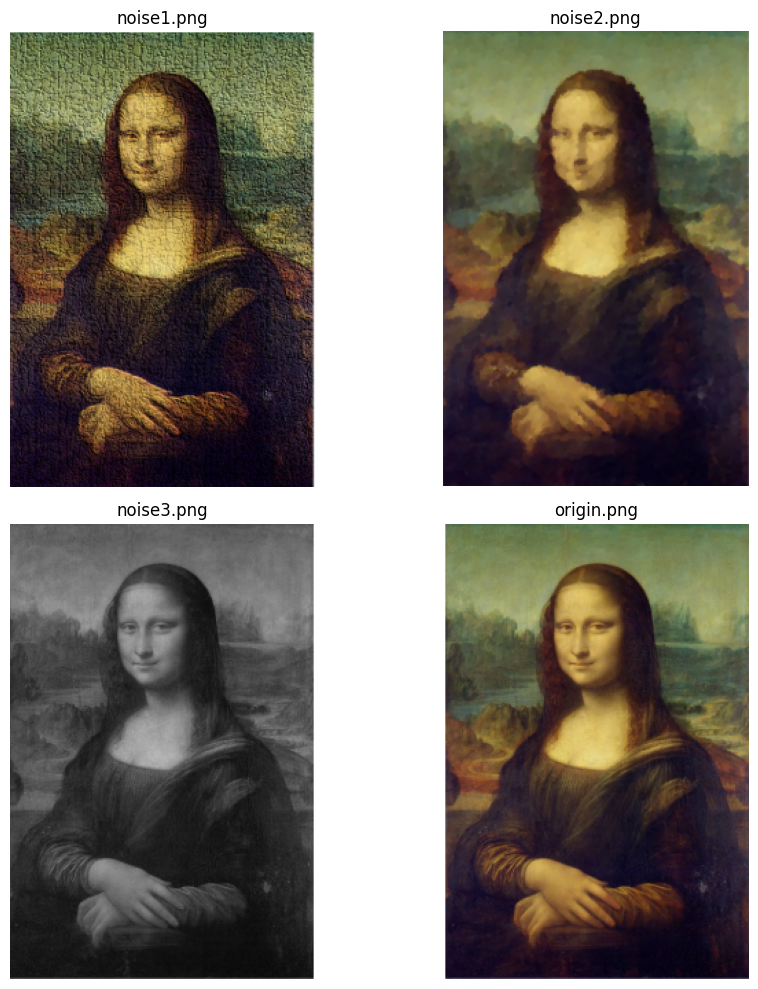

In [29]:
# 1. 폴더 경로 설정
inputdir = Path("For_SSIM")

# 2. 폴더 내의 특정 확장자 파일 모두 찾기 (png, jpg)
image_paths = list(inputdir.glob("*.png")) + list(inputdir.glob("*.jpg"))

if not image_paths:
    print(f"'{inputdir}' 폴더에서 이미지를 찾을 수 없습니다.")
else:
    # 3. 화면 분할 (Grid) 설정
    num_images = len(image_paths)
    cols = 2  # 한 줄에 출력할 이미지 개수 (원하는 대로 수정 가능)
    rows = math.ceil(num_images / cols)

    # 그래프 크기(figsize) 설정
    fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
    
    # 이미지가 1장일 경우 대비 및 다차원 배열 평탄화
    if num_images == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # 4. 이미지 순회하며 출력
    for i, img_path in enumerate(image_paths):
        img = plt.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(img_path.name)  # 파일명을 제목으로 설정
        axes[i].axis('off')  # 지저분한 축(눈금) 숨기기

    # 5. 남는 빈 칸(subplot)이 있다면 숨기기
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()  # 이미지 간 간격 자동 조절
    plt.show()

In [ ]:
load_images = lambda path, h, w: cv2.resize(cv2.cvtColor(cv2.imread(path, cv2.IMREAD_UNCHANGED), cv2.COLOR_BGR2RGB), ((w, h)))
tensorify = lambda x: torch.Tensor(x.transpose((2, 0, 1))).unsqueeze(0).float().div(255.0)

img_tensor = tensorify(load_images("For_SSIM/origin.png", 400, 300))
noise1_tensor = tensorify(load_images("For_SSIM/noise1.png", 400, 300))
noise2_tensor = tensorify(load_images("For_SSIM/noise2.png", 400, 300))
noise3_tensor = tensorify(load_images("For_SSIM/noise3.png", 400, 300))

print(ssim(img_tensor, noise1_tensor), ssim(img_tensor, noise2_tensor), ssim(img_tensor, noise3_tensor))
# tensor(0.4790) tensor(0.8323) tensor(0.7363)

tensor(0.4790) tensor(0.8323) tensor(0.7363)
